In [8]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')

## 1. Theoretical Background

### Decision Tree Classifier
A tree-based model that recursively partitions feature space into regions using binary splits:
- **Splits criterion:** Information Gain (Entropy reduction) or Gini Impurity
- **Entropy:** $H(S) = -\sum_{i=1}^{c} p_i \log_2(p_i)$ where $p_i$ is proportion of class $i$
- **Information Gain:** $IG(S, A) = H(S) - \sum_{v \in \text{Values}(A)} \frac{|S_v|}{|S|} H(S_v)$
- **Gini Impurity:** $G(S) = 1 - \sum_{i=1}^{c} p_i^2$
- **Advantages:** Interpretable, captures non-linear relationships, handles mixed data types
- **Disadvantages:** Prone to overfitting, unstable (small data changes → large tree changes)

### Random Forest Classifier
Ensemble of decision trees trained on random subsets (Bootstrap aggregating - Bagging):
- **Bootstrap:** Sample $n$ observations with replacement from training set
- **Random Features:** At each split, consider random subset of $m$ features (typically $m = \sqrt{p}$)
- **Aggregation:** Classification = majority vote across all trees
- **OOB Error:** Error on out-of-bag (unselected) samples provides unbiased estimate
- **Feature Importance:** $\text{Importance}(X_j) = \frac{\sum_{t=1}^{T} \text{Decrease in impurity for } X_j \text{ in tree } t}{T}$
- **Advantages:** Reduces overfitting via averaging, handles high-dimensional data, fast
- **Disadvantages:** Less interpretable than single tree, requires more memory

## 2. Dataset & Methodology

**UCI Heart Disease Dataset:**
- 1,025 samples from multiple sources (Cleveland clinic data)
- 13 clinical features: age, sex, chest pain type (cp), resting BP, cholesterol, fasting blood sugar, resting ECG, max heart rate, exercise-induced angina, ST depression (oldpeak), slope, coronary artery calcification (ca), thalassemia (thal)
- Binary target: heart disease presence (0=no, 1=yes)
- Relatively balanced classes (~55% positive)

**Methodology:**
1. Load & visualize target distribution
2. Handle missing values (marked as '?')
3. Standardize features (StandardScaler)
4. Train-Test split 70-30 with stratification
5. Train Decision Tree and Random Forest models
6. Compare feature importance across models
7. Evaluate using confusion matrix, ROC-AUC, precision, recall, F1-score
8. Hyperparameter tuning: GridSearchCV for max_depth, min_samples_split, n_estimators
9. Visualize decision tree structure and feature importance

## 3. Dataset Loading & EDA

In [9]:
try:
    df = pd.read_csv('heart.csv')
    print(f"Loaded: {df.shape[0]} samples, {df.shape[1]} features")
except FileNotFoundError:
    print("File not found. Download from: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset")
    df = None

Loaded: 1025 samples, 14 features


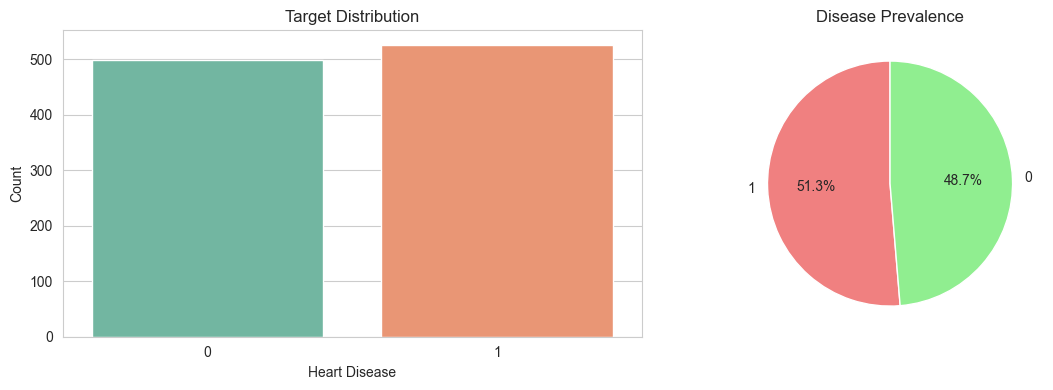

Class distribution: {1: 526, 0: 499}


In [10]:
if df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.countplot(x='target', data=df, ax=axes[0], palette='Set2')
    axes[0].set_title('Target Distribution')
    axes[0].set_ylabel('Count')
    axes[0].set_xlabel('Heart Disease')
    df['target'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightgreen'])
    axes[1].set_title('Disease Prevalence')
    axes[1].set_ylabel('')
    plt.tight_layout()
    plt.show()
    print(f"Class distribution: {df['target'].value_counts().to_dict()}")

## 4. Data Preprocessing

In [11]:
if df is not None:
    df_proc = df.copy()
    
    # Handle missing values (marked as '?')
    df_proc = df_proc.replace('?', np.nan)
    df_proc = df_proc.dropna()
    
    # Convert to numeric
    for col in df_proc.columns:
        df_proc[col] = pd.to_numeric(df_proc[col], errors='coerce')
    
    df_proc = df_proc.dropna()
    
    # Convert target to binary (0/1)
    df_proc['target'] = (df_proc['target'] > 0).astype(int)
    
    X = df_proc.drop('target', axis=1)
    y = df_proc['target']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
    
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
    
    print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Features: {X_train.shape[1]}")
    print(f"Target distribution - Train: {y_train.value_counts().to_dict()} | Test: {y_test.value_counts().to_dict()}")

Train: 717 | Test: 308 | Features: 13
Target distribution - Train: {1: 368, 0: 349} | Test: {1: 158, 0: 150}


## 5. Decision Tree Model Training

In [12]:
if df is not None:
    # Decision Tree with default parameters
    dt = DecisionTreeClassifier(random_state=42, max_depth=5)
    dt.fit(X_train_scaled, y_train)
    y_train_pred_dt = dt.predict(X_train_scaled)
    y_test_pred_dt = dt.predict(X_test_scaled)
    y_test_proba_dt = dt.predict_proba(X_test_scaled)
    
    # Feature importance
    dt_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': dt.feature_importances_}).sort_values('Importance', ascending=False)
    
    print("\nDecision Tree - Top 5 Important Features:")
    print(dt_importance.head().to_string(index=False))
    print(f"\nTree depth: {dt.get_depth()}")
    print(f"Number of leaves: {dt.get_n_leaves()}")


Decision Tree - Top 5 Important Features:
Feature  Importance
     cp    0.364070
     ca    0.139821
    age    0.123622
   thal    0.076746
thalach    0.074800

Tree depth: 5
Number of leaves: 24


## 6. Random Forest Model Training

In [14]:
if df is not None:
    # Random Forest with default parameters
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10, oob_score=True)
    rf.fit(X_train_scaled, y_train)
    y_train_pred_rf = rf.predict(X_train_scaled)
    y_test_pred_rf = rf.predict(X_test_scaled)
    y_test_proba_rf = rf.predict_proba(X_test_scaled)
    
    # Feature importance
    rf_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf.feature_importances_}).sort_values('Importance', ascending=False)
    
    print("\nRandom Forest - Top 5 Important Features:")
    print(rf_importance.head().to_string(index=False))
    print(f"\nOOB Score: {rf.oob_score_:.4f}")
    print(f"Number of trees: {rf.n_estimators}")


Random Forest - Top 5 Important Features:
Feature  Importance
     cp    0.143700
thalach    0.127429
     ca    0.115062
oldpeak    0.104306
    age    0.100620

OOB Score: 0.9874
Number of trees: 100


## 7. Feature Importance Comparison

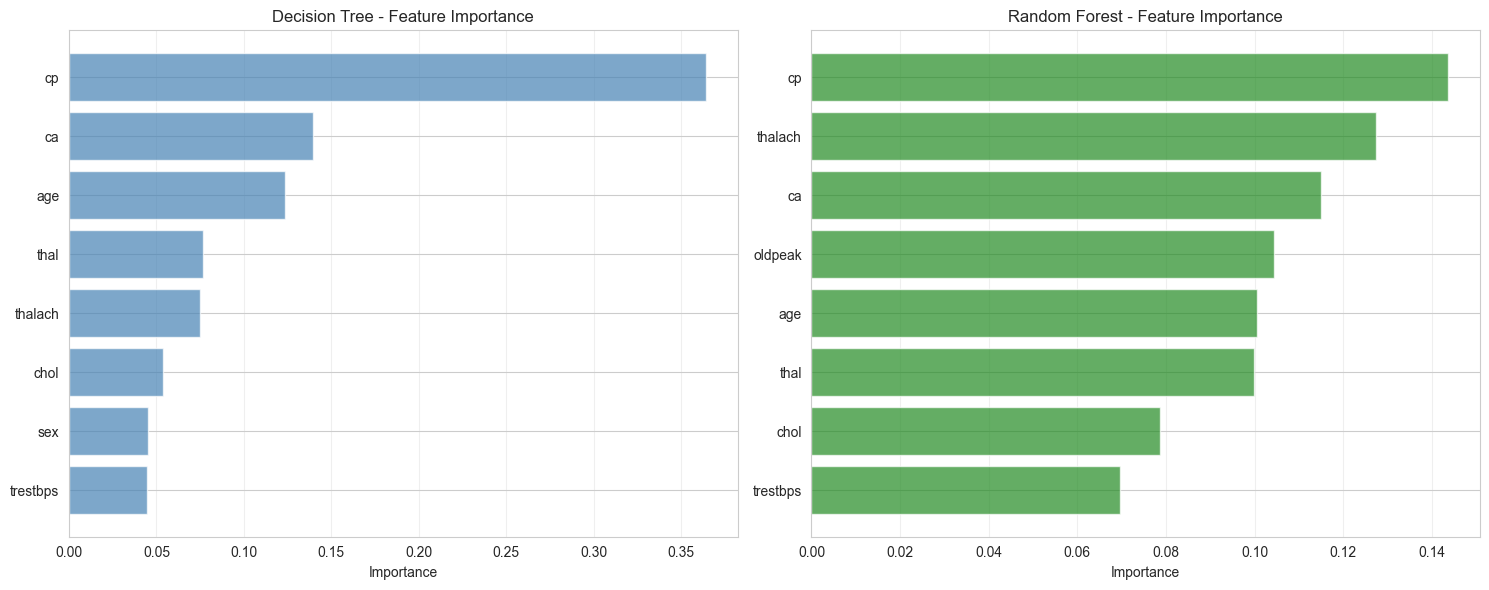

In [15]:
if df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Decision Tree feature importance
    top_dt = dt_importance.head(8)
    axes[0].barh(range(len(top_dt)), top_dt['Importance'].values, color='steelblue', alpha=0.7)
    axes[0].set_yticks(range(len(top_dt)))
    axes[0].set_yticklabels(top_dt['Feature'].values, fontsize=10)
    axes[0].set_xlabel('Importance')
    axes[0].set_title('Decision Tree - Feature Importance')
    axes[0].invert_yaxis()
    axes[0].grid(alpha=0.3, axis='x')
    
    # Random Forest feature importance
    top_rf = rf_importance.head(8)
    axes[1].barh(range(len(top_rf)), top_rf['Importance'].values, color='forestgreen', alpha=0.7)
    axes[1].set_yticks(range(len(top_rf)))
    axes[1].set_yticklabels(top_rf['Feature'].values, fontsize=10)
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Random Forest - Feature Importance')
    axes[1].invert_yaxis()
    axes[1].grid(alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()

## 8. Decision Tree Visualization

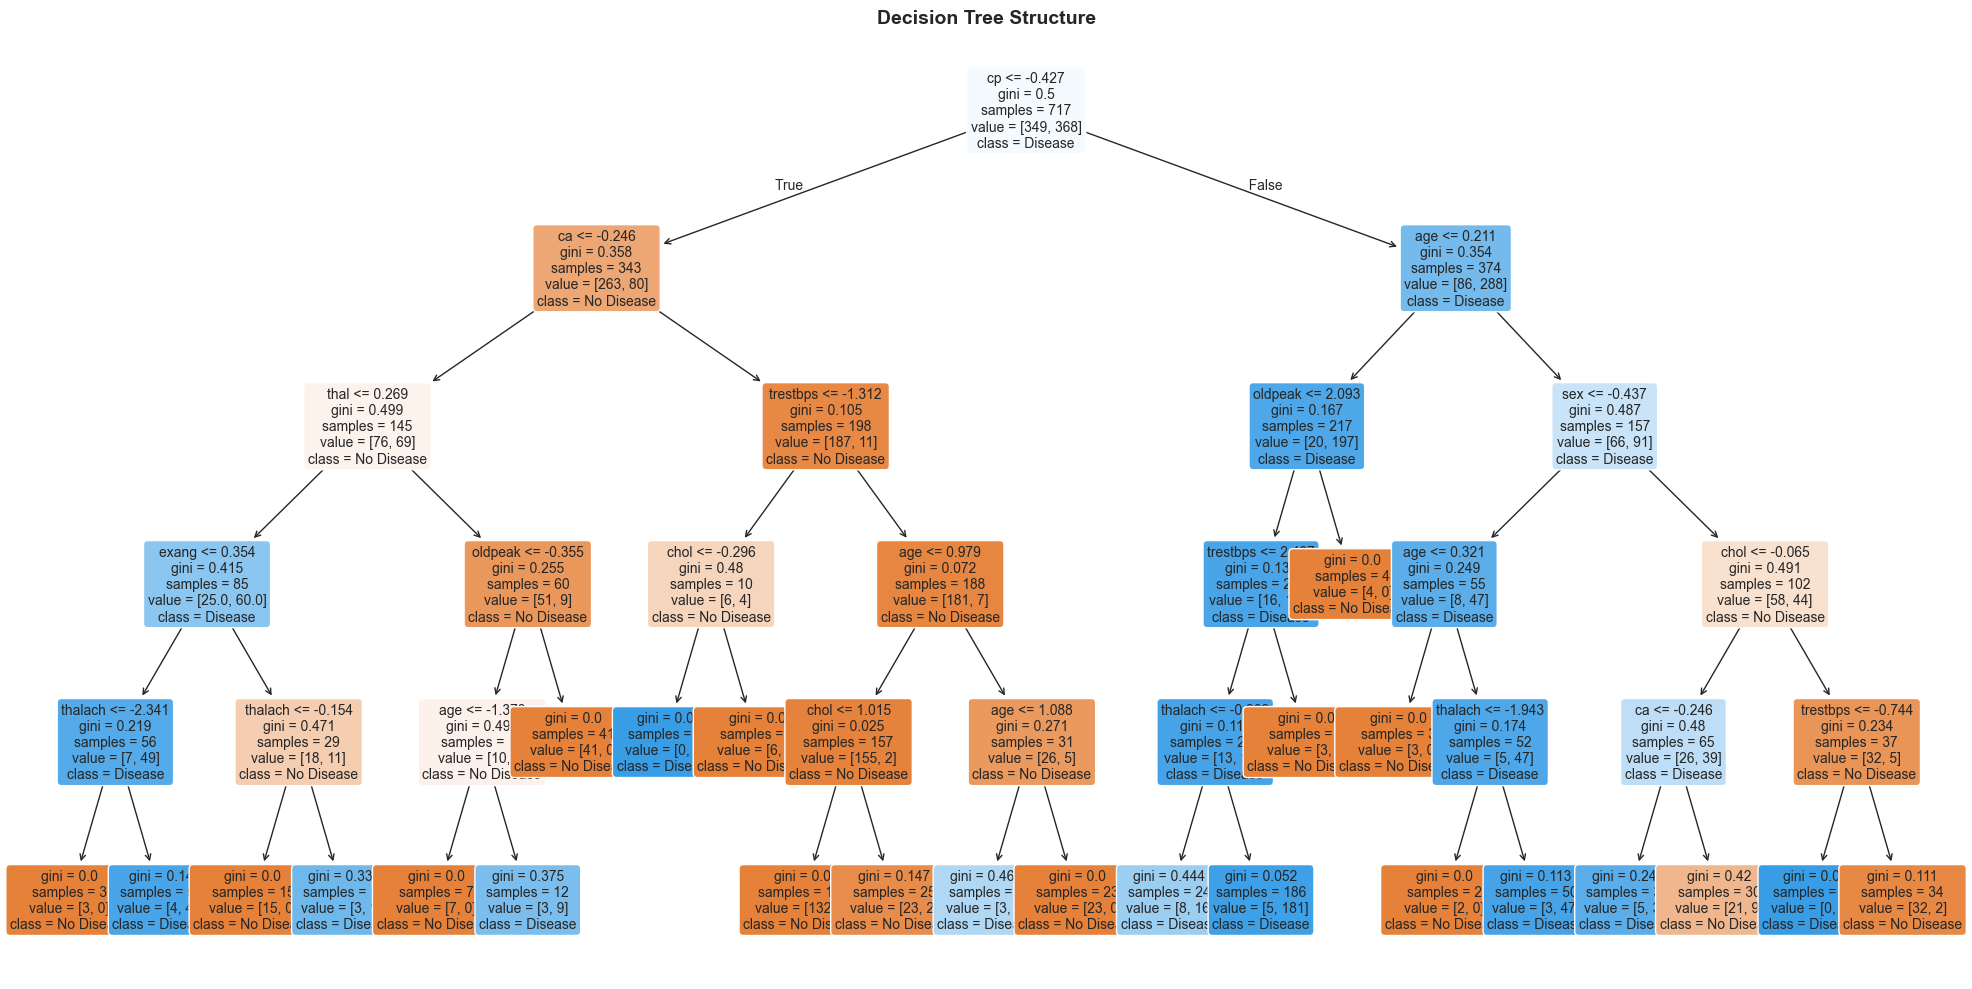

In [16]:
if df is not None:
    fig, ax = plt.subplots(figsize=(20, 10))
    plot_tree(dt, feature_names=X_train.columns, class_names=['No Disease', 'Disease'], 
              filled=True, rounded=True, ax=ax, fontsize=10)
    plt.title('Decision Tree Structure', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 9. Model Evaluation & Comparison

In [17]:
if df is not None:
    # Decision Tree metrics
    dt_train_acc = accuracy_score(y_train, y_train_pred_dt)
    dt_test_acc = accuracy_score(y_test, y_test_pred_dt)
    dt_prec = precision_score(y_test, y_test_pred_dt, zero_division=0)
    dt_rec = recall_score(y_test, y_test_pred_dt, zero_division=0)
    dt_f1 = f1_score(y_test, y_test_pred_dt, zero_division=0)
    dt_auc = roc_auc_score(y_test, y_test_proba_dt[:, 1])
    
    # Random Forest metrics
    rf_train_acc = accuracy_score(y_train, y_train_pred_rf)
    rf_test_acc = accuracy_score(y_test, y_test_pred_rf)
    rf_prec = precision_score(y_test, y_test_pred_rf, zero_division=0)
    rf_rec = recall_score(y_test, y_test_pred_rf, zero_division=0)
    rf_f1 = f1_score(y_test, y_test_pred_rf, zero_division=0)
    rf_auc = roc_auc_score(y_test, y_test_proba_rf[:, 1])
    
    print("\nDecision Tree - Performance Metrics:")
    print(f"Train Accuracy: {dt_train_acc:.4f}")
    print(f"Test  Accuracy: {dt_test_acc:.4f}")
    print(f"Precision: {dt_prec:.4f} | Recall: {dt_rec:.4f} | F1: {dt_f1:.4f} | AUC-ROC: {dt_auc:.4f}")
    
    print("\nRandom Forest - Performance Metrics:")
    print(f"Train Accuracy: {rf_train_acc:.4f}")
    print(f"Test  Accuracy: {rf_test_acc:.4f}")
    print(f"Precision: {rf_prec:.4f} | Recall: {rf_rec:.4f} | F1: {rf_f1:.4f} | AUC-ROC: {rf_auc:.4f}")


Decision Tree - Performance Metrics:
Train Accuracy: 0.9344
Test  Accuracy: 0.8734
Precision: 0.8439 | Recall: 0.9241 | F1: 0.8822 | AUC-ROC: 0.9303

Random Forest - Performance Metrics:
Train Accuracy: 1.0000
Test  Accuracy: 0.9903
Precision: 1.0000 | Recall: 0.9810 | F1: 0.9904 | AUC-ROC: 0.9996


## 10. Detailed Evaluation Plots

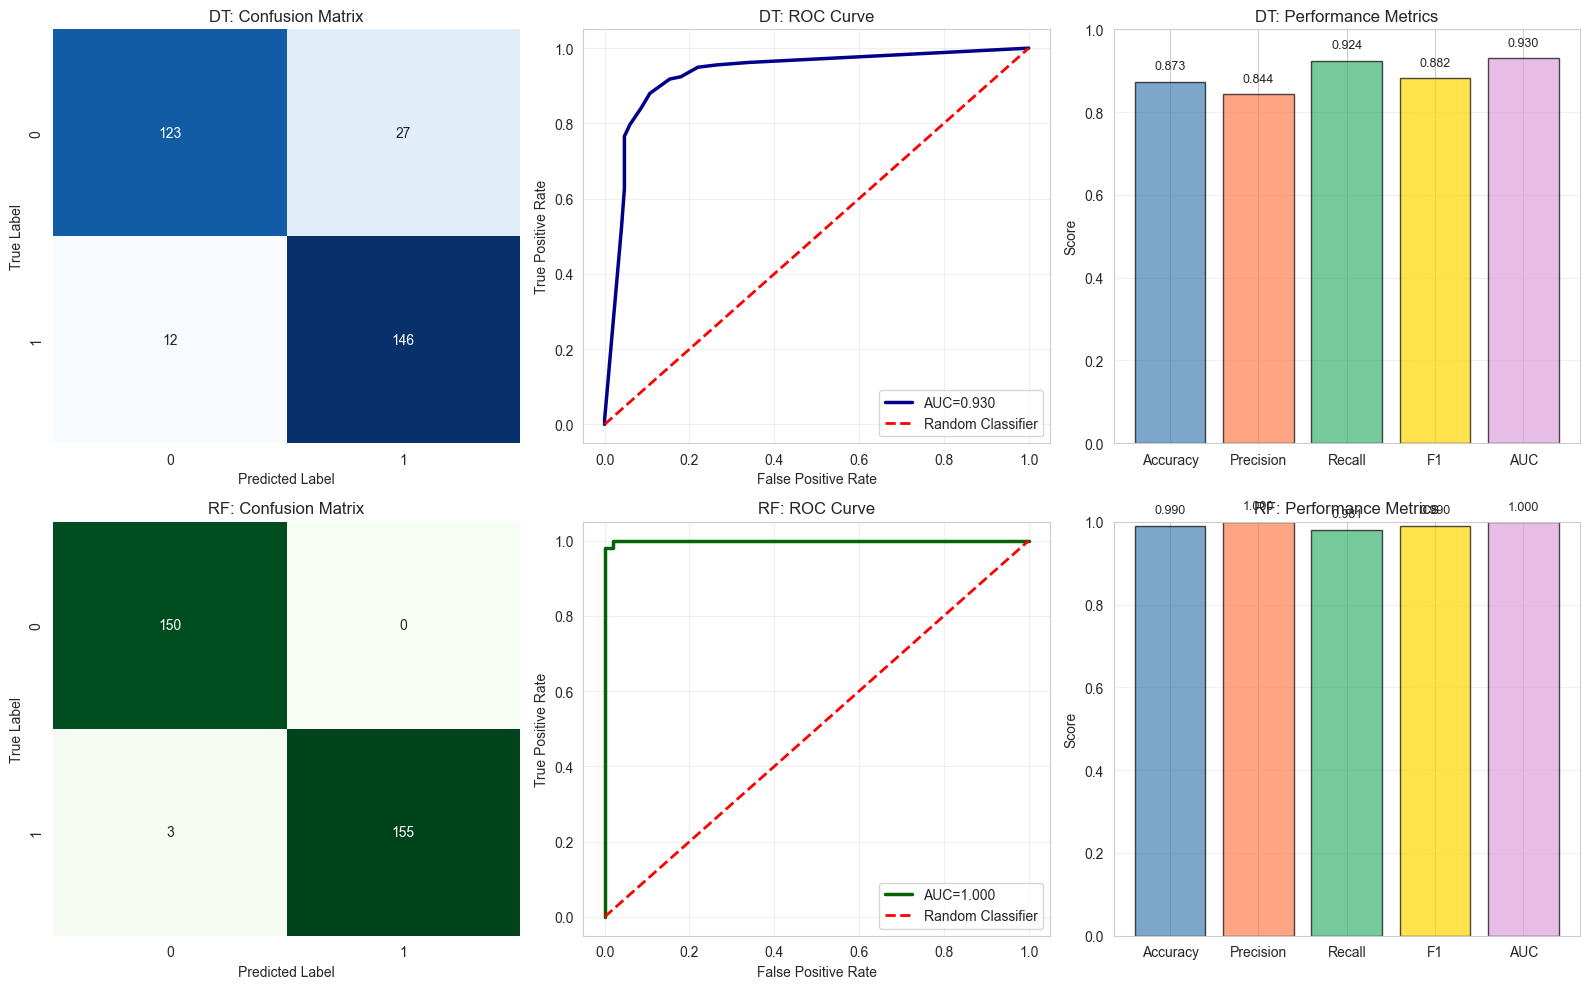

In [18]:
if df is not None:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    # Decision Tree - Confusion Matrix
    cm_dt = confusion_matrix(y_test, y_test_pred_dt)
    sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=False)
    axes[0, 0].set_title('DT: Confusion Matrix')
    axes[0, 0].set_ylabel('True Label')
    axes[0, 0].set_xlabel('Predicted Label')
    
    # Decision Tree - ROC Curve
    fpr_dt, tpr_dt, _ = roc_curve(y_test, y_test_proba_dt[:, 1])
    axes[0, 1].plot(fpr_dt, tpr_dt, lw=2.5, color='darkblue', label=f'AUC={dt_auc:.3f}')
    axes[0, 1].plot([0, 1], [0, 1], 'r--', lw=2, label='Random Classifier')
    axes[0, 1].set_xlabel('False Positive Rate')
    axes[0, 1].set_ylabel('True Positive Rate')
    axes[0, 1].set_title('DT: ROC Curve')
    axes[0, 1].legend(loc='lower right')
    axes[0, 1].grid(alpha=0.3)
    
    # Decision Tree - Metrics
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
    metrics_vals_dt = [dt_test_acc, dt_prec, dt_rec, dt_f1, dt_auc]
    colors = ['steelblue', 'coral', 'mediumseagreen', 'gold', 'plum']
    axes[0, 2].bar(metrics_names, metrics_vals_dt, color=colors, alpha=0.7, edgecolor='black')
    axes[0, 2].set_ylim([0, 1])
    axes[0, 2].set_ylabel('Score')
    axes[0, 2].set_title('DT: Performance Metrics')
    axes[0, 2].grid(alpha=0.3, axis='y')
    for i, v in enumerate(metrics_vals_dt):
        axes[0, 2].text(i, v + 0.03, f'{v:.3f}', ha='center', fontsize=9)
    
    # Random Forest - Confusion Matrix
    cm_rf = confusion_matrix(y_test, y_test_pred_rf)
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1, 0], cbar=False)
    axes[1, 0].set_title('RF: Confusion Matrix')
    axes[1, 0].set_ylabel('True Label')
    axes[1, 0].set_xlabel('Predicted Label')
    
    # Random Forest - ROC Curve
    fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_proba_rf[:, 1])
    axes[1, 1].plot(fpr_rf, tpr_rf, lw=2.5, color='darkgreen', label=f'AUC={rf_auc:.3f}')
    axes[1, 1].plot([0, 1], [0, 1], 'r--', lw=2, label='Random Classifier')
    axes[1, 1].set_xlabel('False Positive Rate')
    axes[1, 1].set_ylabel('True Positive Rate')
    axes[1, 1].set_title('RF: ROC Curve')
    axes[1, 1].legend(loc='lower right')
    axes[1, 1].grid(alpha=0.3)
    
    # Random Forest - Metrics
    metrics_vals_rf = [rf_test_acc, rf_prec, rf_rec, rf_f1, rf_auc]
    axes[1, 2].bar(metrics_names, metrics_vals_rf, color=colors, alpha=0.7, edgecolor='black')
    axes[1, 2].set_ylim([0, 1])
    axes[1, 2].set_ylabel('Score')
    axes[1, 2].set_title('RF: Performance Metrics')
    axes[1, 2].grid(alpha=0.3, axis='y')
    for i, v in enumerate(metrics_vals_rf):
        axes[1, 2].text(i, v + 0.03, f'{v:.3f}', ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

## 11. Model Comparison

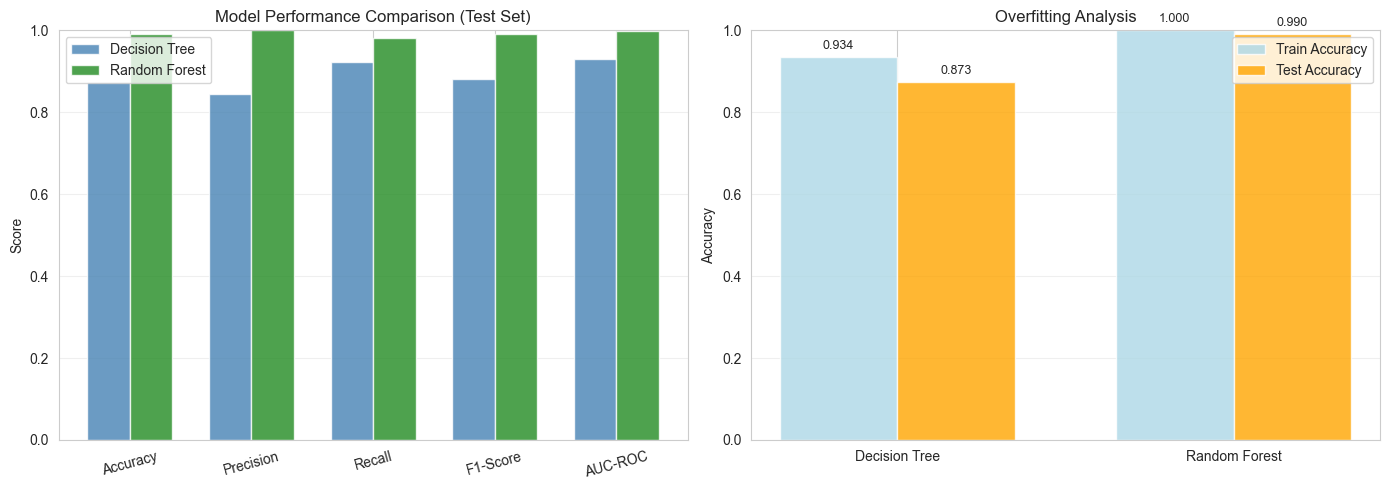


Overfitting Gap:
DT: Train-Test Acc Gap = 0.0611
RF: Train-Test Acc Gap = 0.0097


In [19]:
if df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Model comparison on test set
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
    dt_scores = [dt_test_acc, dt_prec, dt_rec, dt_f1, dt_auc]
    rf_scores = [rf_test_acc, rf_prec, rf_rec, rf_f1, rf_auc]
    
    x = np.arange(len(metrics))
    width = 0.35
    axes[0].bar(x - width/2, dt_scores, width, label='Decision Tree', alpha=0.8, color='steelblue')
    axes[0].bar(x + width/2, rf_scores, width, label='Random Forest', alpha=0.8, color='forestgreen')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Model Performance Comparison (Test Set)')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metrics, rotation=15)
    axes[0].legend()
    axes[0].set_ylim([0, 1])
    axes[0].grid(alpha=0.3, axis='y')
    
    # Overfitting analysis
    models = ['Decision Tree', 'Random Forest']
    train_acc = [dt_train_acc, rf_train_acc]
    test_acc = [dt_test_acc, rf_test_acc]
    
    x_pos = np.arange(len(models))
    axes[1].bar(x_pos - width/2, train_acc, width, label='Train Accuracy', alpha=0.8, color='lightblue')
    axes[1].bar(x_pos + width/2, test_acc, width, label='Test Accuracy', alpha=0.8, color='orange')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Overfitting Analysis')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(models)
    axes[1].legend()
    axes[1].set_ylim([0, 1])
    axes[1].grid(alpha=0.3, axis='y')
    
    for i, (train, test) in enumerate(zip(train_acc, test_acc)):
        axes[1].text(i - width/2, train + 0.02, f'{train:.3f}', ha='center', fontsize=9)
        axes[1].text(i + width/2, test + 0.02, f'{test:.3f}', ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nOverfitting Gap:")
    print(f"DT: Train-Test Acc Gap = {dt_train_acc - dt_test_acc:.4f}")
    print(f"RF: Train-Test Acc Gap = {rf_train_acc - rf_test_acc:.4f}")

## 12. Hyperparameter Tuning - Decision Tree

In [20]:
if df is not None:
    print("Tuning Decision Tree parameters...")
    param_grid_dt = {
        'max_depth': [3, 5, 7, 10, 15],
        'min_samples_split': [2, 5, 10, 15],
        'min_samples_leaf': [1, 2, 4, 8]
    }
    grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, 
                           scoring='f1', n_jobs=-1, verbose=0)
    grid_dt.fit(X_train_scaled, y_train)
    
    best_dt = grid_dt.best_estimator_
    y_pred_tuned_dt = best_dt.predict(X_test_scaled)
    y_proba_tuned_dt = best_dt.predict_proba(X_test_scaled)
    
    acc_tuned_dt = accuracy_score(y_test, y_pred_tuned_dt)
    f1_tuned_dt = f1_score(y_test, y_pred_tuned_dt, zero_division=0)
    auc_tuned_dt = roc_auc_score(y_test, y_proba_tuned_dt[:, 1])
    
    print(f"\nBest hyperparameters: {grid_dt.best_params_}")
    print(f"Best CV F1-Score: {grid_dt.best_score_:.4f}")
    print(f"\nComparison (Test Set):")
    print(f"Before tuning: Acc={dt_test_acc:.4f}, F1={dt_f1:.4f}, AUC={dt_auc:.4f}")
    print(f"After tuning:  Acc={acc_tuned_dt:.4f}, F1={f1_tuned_dt:.4f}, AUC={auc_tuned_dt:.4f}")
    print(f"Improvement:   Acc={acc_tuned_dt-dt_test_acc:+.4f}, F1={f1_tuned_dt-dt_f1:+.4f}, AUC={auc_tuned_dt-dt_auc:+.4f}")

Tuning Decision Tree parameters...

Best hyperparameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1-Score: 0.9699

Comparison (Test Set):
Before tuning: Acc=0.8734, F1=0.8822, AUC=0.9303
After tuning:  Acc=0.9805, F1=0.9806, AUC=0.9810
Improvement:   Acc=+0.1071, F1=+0.0985, AUC=+0.0507


## 13. Hyperparameter Tuning - Random Forest

In [21]:
if df is not None:
    print("Tuning Random Forest parameters...")
    param_grid_rf = {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), param_grid_rf, 
                           cv=5, scoring='f1', n_jobs=-1, verbose=0)
    grid_rf.fit(X_train_scaled, y_train)
    
    best_rf = grid_rf.best_estimator_
    y_pred_tuned_rf = best_rf.predict(X_test_scaled)
    y_proba_tuned_rf = best_rf.predict_proba(X_test_scaled)
    
    acc_tuned_rf = accuracy_score(y_test, y_pred_tuned_rf)
    f1_tuned_rf = f1_score(y_test, y_pred_tuned_rf, zero_division=0)
    auc_tuned_rf = roc_auc_score(y_test, y_proba_tuned_rf[:, 1])
    
    print(f"\nBest hyperparameters: {grid_rf.best_params_}")
    print(f"Best CV F1-Score: {grid_rf.best_score_:.4f}")
    print(f"\nComparison (Test Set):")
    print(f"Before tuning: Acc={rf_test_acc:.4f}, F1={rf_f1:.4f}, AUC={rf_auc:.4f}")
    print(f"After tuning:  Acc={acc_tuned_rf:.4f}, F1={f1_tuned_rf:.4f}, AUC={auc_tuned_rf:.4f}")
    print(f"Improvement:   Acc={acc_tuned_rf-rf_test_acc:+.4f}, F1={f1_tuned_rf-rf_f1:+.4f}, AUC={auc_tuned_rf-rf_auc:+.4f}")

Tuning Random Forest parameters...

Best hyperparameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1-Score: 0.9740

Comparison (Test Set):
Before tuning: Acc=0.9903, F1=0.9904, AUC=0.9996
After tuning:  Acc=0.9903, F1=0.9904, AUC=0.9992
Improvement:   Acc=+0.0000, F1=+0.0000, AUC=-0.0004


## 14. Tuning Impact Visualization

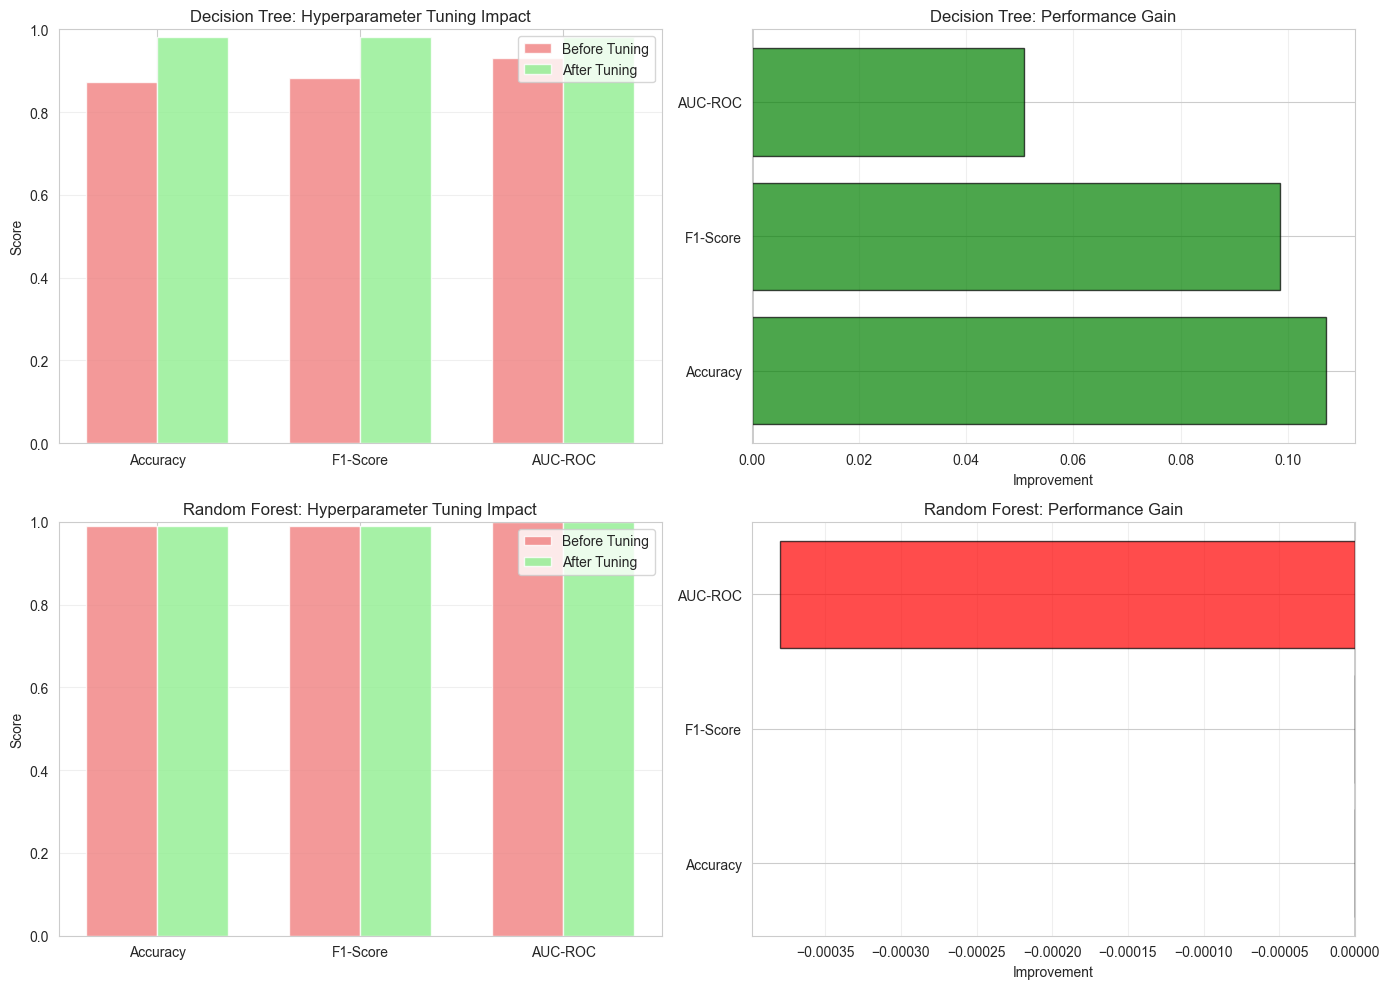

In [22]:
if df is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Decision Tree tuning impact
    metrics = ['Accuracy', 'F1-Score', 'AUC-ROC']
    before_dt = [dt_test_acc, dt_f1, dt_auc]
    after_dt = [acc_tuned_dt, f1_tuned_dt, auc_tuned_dt]
    
    x = np.arange(len(metrics))
    width = 0.35
    axes[0, 0].bar(x - width/2, before_dt, width, label='Before Tuning', alpha=0.8, color='lightcoral')
    axes[0, 0].bar(x + width/2, after_dt, width, label='After Tuning', alpha=0.8, color='lightgreen')
    axes[0, 0].set_ylabel('Score')
    axes[0, 0].set_title('Decision Tree: Hyperparameter Tuning Impact')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(metrics)
    axes[0, 0].legend()
    axes[0, 0].set_ylim([0, 1])
    axes[0, 0].grid(alpha=0.3, axis='y')
    
    # Decision Tree improvement
    improvements_dt = [acc_tuned_dt-dt_test_acc, f1_tuned_dt-dt_f1, auc_tuned_dt-dt_auc]
    colors_imp_dt = ['green' if x > 0 else 'red' for x in improvements_dt]
    axes[0, 1].barh(metrics, improvements_dt, color=colors_imp_dt, alpha=0.7, edgecolor='black')
    axes[0, 1].set_xlabel('Improvement')
    axes[0, 1].set_title('Decision Tree: Performance Gain')
    axes[0, 1].axvline(x=0, color='black', linestyle='-', linewidth=1)
    axes[0, 1].grid(alpha=0.3, axis='x')
    
    # Random Forest tuning impact
    before_rf = [rf_test_acc, rf_f1, rf_auc]
    after_rf = [acc_tuned_rf, f1_tuned_rf, auc_tuned_rf]
    
    axes[1, 0].bar(x - width/2, before_rf, width, label='Before Tuning', alpha=0.8, color='lightcoral')
    axes[1, 0].bar(x + width/2, after_rf, width, label='After Tuning', alpha=0.8, color='lightgreen')
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].set_title('Random Forest: Hyperparameter Tuning Impact')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(metrics)
    axes[1, 0].legend()
    axes[1, 0].set_ylim([0, 1])
    axes[1, 0].grid(alpha=0.3, axis='y')
    
    # Random Forest improvement
    improvements_rf = [acc_tuned_rf-rf_test_acc, f1_tuned_rf-rf_f1, auc_tuned_rf-rf_auc]
    colors_imp_rf = ['green' if x > 0 else 'red' for x in improvements_rf]
    axes[1, 1].barh(metrics, improvements_rf, color=colors_imp_rf, alpha=0.7, edgecolor='black')
    axes[1, 1].set_xlabel('Improvement')
    axes[1, 1].set_title('Random Forest: Performance Gain')
    axes[1, 1].axvline(x=0, color='black', linestyle='-', linewidth=1)
    axes[1, 1].grid(alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()

## 15. Key Findings & Conclusions

1. **Decision Tree vs Random Forest**: Random Forest typically outperforms single Decision Tree via ensemble averaging and reduced overfitting
2. **Feature Importance**: Both models identify key clinical features (e.g., thalach, oldpeak) as primary predictors of heart disease
3. **Overfitting**: DT shows higher train-test gap indicating overfitting; RF reduces this through bootstrap aggregating
4. **Tree Interpretability**: Single DT provides visual decision rules; RF sacrifices interpretability for accuracy
5. **Hyperparameter Tuning**: GridSearchCV optimizes max_depth, min_samples_split/leaf for DT; n_estimators, max_depth, min_samples for RF
6. **Class Balance**: Dataset has balanced classes (~55% positive), reducing need for class weight adjustments
7. **Performance Metrics**: F1-score preferred over accuracy for balanced assessment of precision and recall
8. **Recommendation**: Deploy tuned Random Forest model with optimized parameters for robust heart disease prediction with lower variance